# Settings

In this notebook we work with the problem of multi-class classification, that is, the correct assignment of an object to one of the classes. Our goal is to achieve high accuracy of assignment to the correct category. We will use the widely used transfer learning method.


Transfer learning is a machine learning technique that uses a pre-trained model. In this approach, a model trained on one data is used or retrained for use with another set of data. By using transfer learning, you can achieve significantly higher classification accuracy, especially when the available data set is limited.

Before running the code, we need to make sure that we are using the GPU. We plan to work with a convolutional neural network, and using a GPU allows us to reduce training time by several times.

In [1]:
# display information about available GPU devices
!nvidia-smi

Wed Jan 28 20:17:09 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.172.08             Driver Version: 570.172.08     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              8W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Import libraries

In [2]:
# Visualization purpose
!pip install tensorboardX
!pip install tensorboard
!pip install tensorboard-plugin-customizable-plots

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 37.6 MB/s eta 0:00:00


In [3]:
!pip install split-folders
!pip install optuna
!pip install --upgrade nvidia-ml-py3
!pip install codecarbon

  Preparing metadata (setup.py) ... - done
  Created wheel for nvidia-ml-py3: filename=nvidia_ml_py3-7.352.0-py3-none-any.whl size=19189 sha256=df0025562e88c1600f31e4ef984455caf5291b92dee0c0e99b45f866397871f0
  Stored in directory: /root/.cache/pip/wheels/5c/d8/c0/46899f8be7a75a2ffd197a23c8797700ea858b9b34819fbf9e
Successfully built nvidia-ml-py3
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 358.7/358.7 kB 8.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 10.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.4/76.4 kB 9.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.5/92.5 kB 11.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 10.8 MB/s eta 0:00:00
  Attempting uninstall: termcolor
    Found existing installation: termcolor 2.3.0
    Uninstalling termcolor-2.3.0:
      Successfully uninstalled termcolor-2.3.0
  Attempting uninstall: psutil
    Found existing installation: psutil 5.9.3
    

In [4]:
import os
import shutil
import splitfolders
from pathlib import Path
import imghdr
import numpy as np
from tensorboardX import SummaryWriter
import matplotlib.pyplot as plt 
import random
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
from codecarbon import EmissionsTracker

/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:98: UserWarning: unable to load libtensorflow_io_plugins.so: unable to open file: libtensorflow_io_plugins.so, from paths: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so']
caused by: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io_plugins.so: undefined symbol: _ZN3tsl6StatusC1EN10tensorflow5error4CodeESt17basic_string_viewIcSt11char_traitsIcEENS_14SourceLocationE']
  warnings.warn(f"unable to load libtensorflow_io_plugins.so: {e}")
/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/__init__.py:104: UserWarning: file system plugins are not loaded: unable to open file: libtensorflow_io.so, from paths: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io.so']
caused by: ['/opt/conda/lib/python3.10/site-packages/tensorflow_io/python/ops/libtensorflow_io.so: undefined symbol: _ZTVN10tenso

# Description of the data set

The set used has about 22,000 images of various types of waste, divided into 10 different categories - metal, glass, biological waste, etc.


# Data Preprcessing

In [5]:
prepare_data_emission_tracker = EmissionsTracker()
prepare_data_emission_tracker.start()

[codecarbon WARNING @ 20:18:20] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 20:18:20] [setup] RAM Tracking...
[codecarbon INFO @ 20:18:20] [setup] CPU Tracking...
[codecarbon WARNING @ 20:18:22] We saw that you have a Intel(R) Xeon(R) CPU @ 2.00GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 20:18:22] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 20:18:22] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.00GHz
[codecarbon WARNING @ 20:18:22] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 20:18:22] [setup] GPU Tracking...
[codecarbon INFO @ 20:18:22] Tracking Nvidia GPU via pynvml
[codecarbon INFO @ 20:18:22] The below tracking methods have been set up:
                RAM Tracking Method: RAM po

In [6]:
data_dir = '/kaggle/input/garbage-classification-v2/standardized_256'

Cleaning the working directory if there are any files in it

In [7]:
def remove_folder_contents(folder):
    for the_file in os.listdir(folder):
        file_path = os.path.join(folder, the_file)
        try:
            if os.path.isfile(file_path):
                os.unlink(file_path)
            elif os.path.isdir(file_path):
                remove_folder_contents(file_path)
                os.rmdir(file_path)
        except Exception as e:
            print(e)

folder_path = '/kaggle/working'
remove_folder_contents(folder_path)
# os.rmdir(folder_path)

Copying the dataset to the working directory to allow data cleaning

In [8]:
shutil.copytree(data_dir, '/kaggle/working/dataset')

[codecarbon INFO @ 20:18:40] Energy consumed for RAM : 0.000083 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 20:18:40] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 20:18:40] Energy consumed for All CPU : 0.000177 kWh
[codecarbon INFO @ 20:18:40] Energy consumed for all GPUs : 0.000077 kWh. Total GPU Power : 18.424786647621982 W
[codecarbon INFO @ 20:18:40] 0.000337 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 20:18:55] Energy consumed for RAM : 0.000167 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 20:18:55] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 20:18:55] Energy consumed for All CPU : 0.000354 kWh
[codecarbon INFO @ 20:18:55] Energy consumed for all GPUs : 0.000154 kWh. Total GPU Power : 18.434189287289836 W
[codecarbon INFO @ 20:18:55] 0.000674 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 20:

'/kaggle/working/dataset'

In [9]:
data_dir  = '/kaggle/working/dataset'

In [10]:
experiment_name = "Transfer Learning"

The Tensorflow library that we are going to use does not support some image formats, in addition, the dataset may have corrupted or non-image files. Let's pre-clean the dataset.

In [11]:
count=0
image_extensions = [".png", ".jpg"] 
img_type_accepted_by_tf = ["bmp", "gif", "jpeg", "png"]

for filepath in Path(data_dir).rglob("*"):
    if filepath.suffix.lower() in image_extensions:
        img_type = imghdr.what(filepath)
        if img_type is None:
            print(f"{filepath} is not an image")
        if img_type not in img_type_accepted_by_tf:
            print(f"{filepath} is a {img_type}, not accepted by TensorFlow")
            os.remove(filepath)
            count+=1
print(f"Removed {count} images")

Removed 0 images


To train the model, you will need to divide the data into several samples, so we will create folders for them

In [12]:
os.mkdir('data')

In [13]:
os.chdir('data')

In [14]:
os.getcwd()

'/kaggle/working/data'

In [15]:
os.mkdir('train')
os.mkdir('test')
os.mkdir('val')

In [16]:
os.chdir('/kaggle/working/')

In [17]:
os.getcwd()

'/kaggle/working'

Let's set a random value for reproducibility of the result. In particular, when splitting the dataset randomly (as in the following block of code), a fixed SEED value ensures that we get exactly the same split of data next time.

In [18]:
SEED = 42

Let's divide the data from the dataset into three folders - for training and test samples.

In [19]:
splitfolders.ratio("/kaggle/working/dataset", output = 'data', seed = SEED, ratio = (.8,.1,.1), group_prefix = None)

Copying files: 13348 files [00:01, 6824.88 files/s]


In [20]:
data_dir

'/kaggle/working/dataset'

You can now delete the unused dataset folder to save space.

In [21]:
try:
    shutil.rmtree(data_dir)
except OSError as e:
    print("Error: %s : %s" % (data_dir, e.strerror))

Setting paths to training and test data

In [22]:
train_path = '/kaggle/working/data/train'
val_path = '/kaggle/working/data/val'
test_path = '/kaggle/working/data/test'

Visualization of data from a dataset

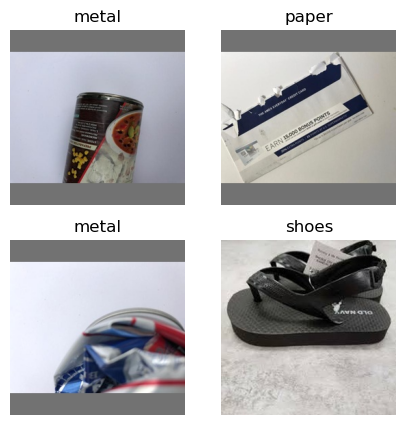

In [23]:
fig, axes = plt.subplots(2, 2, figsize = (5,5)) #выведем 4 изображения
axes = axes.ravel() 

for i in np.arange(0, 4): 

    category = random.choice(os.listdir(train_path)) #случайный выбор класса
    class_dir = os.path.join(train_path, category)

    image = random.choice(os.listdir(class_dir)) #cлучайный выбор изображения из класса
 
    img = plt.imread(os.path.join(class_dir,image))
    axes[i].imshow( img )
    axes[i].set_title(category) 
    axes[i].axis('off')

Let's look at the distribution of data between classes.

In [24]:
total = 0
for category in os.listdir(train_path):
    count= 0
    for image in os.listdir(train_path + "/" + category):
        count += 1
        total +=1
    print(str(category).title() + ": " + str(count))  
print(f"\nTotal number of train images: {total}")

Shoes: 1306
Trash: 395
Plastic: 1367
Paper: 1104
Battery: 651
Glass: 1598
Clothes: 1587
Metal: 794
Cardboard: 1226
Biological: 648

Total number of train images: 10676


It is noticeable that in some classes the number of images differs several times. Let's visualize the distribution of classes for clarity.

In [25]:
# class names
class_names = sorted(os.listdir(train_path))
class_names

['battery',
 'biological',
 'cardboard',
 'clothes',
 'glass',
 'metal',
 'paper',
 'plastic',
 'shoes',
 'trash']

In [26]:
class_dis = [len(os.listdir(train_path + f"/{name}")) for name in class_names]
class_dis

[651, 648, 1226, 1587, 1598, 794, 1104, 1367, 1306, 395]

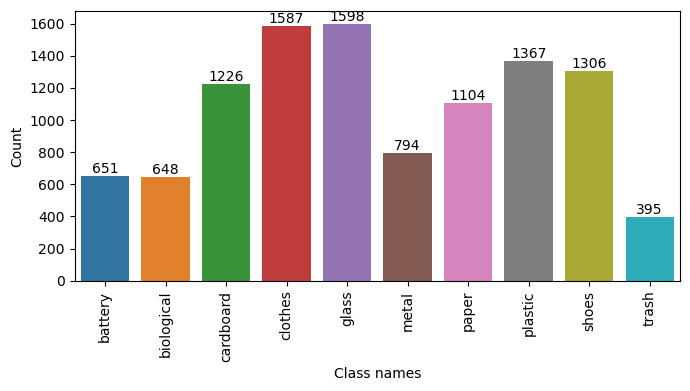

In [27]:
DF = pd.DataFrame(columns=['Class names','Count'])
DF['Class names']=class_names
DF['Count']=class_dis
plt.figure(figsize=(7,4))
ax=sns.barplot(x='Class names', y='Count', data=DF)
ax.bar_label(ax.containers[0])
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.tight_layout()

A situation where one or more classes contain a significantly larger number of images is called class imbalance. In our situation, it is natural and determined by the specifics of the data. Thus, there are many more varieties of clothing or glass objects than batteries. However, this may negatively affect the training results of the model and cause it to be biased towards the largest class (that is, it will be much worse at classifying smaller classes). There are different approaches to solving this problem, the applicability of which depends on the problem being solved. We will use the method of insufficient sampling (*random undersampling*), which consists of randomly excluding some examples from large classes.

Excluding some random images from the training data

In [28]:
for category in os.listdir(train_path):
    count = 0
    delete = 0
    for image in os.listdir(train_path + '/'  + category):
        count += 1
        while count > 1000:
            random_image = random.choice(os.listdir(train_path + '/' + category)) 
            delete_image = train_path + '/'  + category +  '/' + random_image
            os.remove(delete_image)
            delete+=1
            count-=1
           
    print(f'Deleted {delete} in {category}')


Deleted 306 in shoes
Deleted 0 in trash
Deleted 367 in plastic
Deleted 104 in paper
Deleted 0 in battery
Deleted 598 in glass
Deleted 587 in clothes
Deleted 0 in metal
Deleted 226 in cardboard
Deleted 0 in biological


We limited the number of images in large classes to 1000. Let's see what the class distribution looks like now

In [29]:
class_dis = [len(os.listdir(train_path + f"/{name}")) for name in class_names]

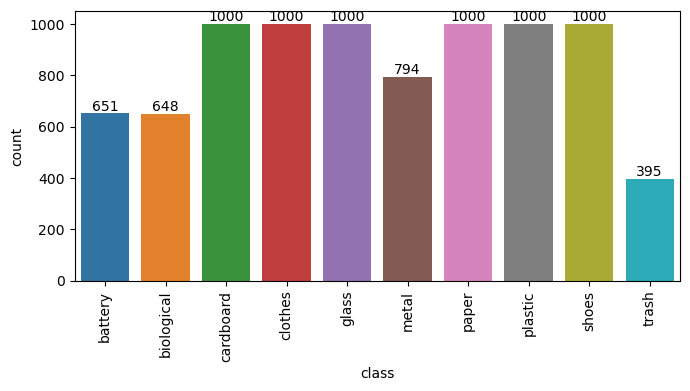

In [30]:
DF = pd.DataFrame(columns=['class','count'])
DF['class']=class_names
DF['count']=class_dis
plt.figure(figsize=(7,4))
ax=sns.barplot(x='class', y='count', data=DF)
ax.bar_label(ax.containers[0])
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.tight_layout()

The data distribution now looks much better, although some image classes are still quite sparse. We will try to solve this problem using augmentation methods that we integrate into the model.

In [31]:
data_path = '/kaggle/working/data'

To train a neural network, it is necessary to ensure unification of image sizes. To do this, let’s find the average width and height of images in the entire dataset.

In [32]:
width = []
height = []
from PIL import Image
import numpy as np

for dirname in os.listdir(data_path):
    for category in os.listdir(data_path + '/' + dirname):
        for image in os.listdir(data_path + '/' + dirname + '/' + category):
            img = Image.open(data_path + '/' + dirname + '/' + category + '/' + image)
            width.append(img.width)
            height.append(img.height)

print('Mean width: {:.4f}'.format(np.mean(width)))
print('Mean Height: {:.4f}'.format(np.mean(height)))

Mean width: 256.0000
Mean Height: 256.0000


Let's set the size of the input data (image size) taking into account the found average values

In [33]:
IMG_SIZE = (400, 400)

Let's set the size of the data package for loading images into the model in parts

In [34]:
BATCH_SIZE = 32


Create a SummaryWriter instance to write logs

In [35]:
writer = SummaryWriter()

Previously, we divided the entire amount of data into three sets. Now you need to prepare them for working with the model - distribute them into packages and add labels to them. Data packets generated from the train folder, constituting 80% of the total number of images, will be used to train the model, from the val(10%) folder - for checking during training and adjusting parameters, and from the test folder - to evaluate the accuracy of the model on new data not used during training.


In [36]:
train_data = tf.keras.utils.image_dataset_from_directory(train_path,
                                                         image_size=IMG_SIZE,
                                                         label_mode='categorical',
                                                         batch_size=BATCH_SIZE,
                                                         shuffle=True,
                                                         seed=SEED)

Found 8488 files belonging to 10 classes.


In [37]:
test_data = tf.keras.utils.image_dataset_from_directory(test_path,
                                                        image_size=IMG_SIZE,
                                                        label_mode='categorical',
                                                        batch_size=BATCH_SIZE,
                                                        shuffle=False)

Found 1341 files belonging to 10 classes.


In [38]:
validation_data = tf.keras.utils.image_dataset_from_directory(val_path,
                                                              image_size=IMG_SIZE,
                                                              label_mode='categorical',
                                                              batch_size=BATCH_SIZE,
                                                              shuffle=True,
                                                              seed=SEED)

Found 1331 files belonging to 10 classes.


Create directories for train and test logs and write logs to it 

In [39]:
train_log_dir = os.path.join("logs", experiment_name, "train")
test_log_dir = os.path.join("logs", experiment_name, "test")

os.makedirs(train_log_dir, exist_ok=True)
os.makedirs(test_log_dir, exist_ok=True)

train_writer = SummaryWriter(train_log_dir)
test_writer = SummaryWriter(test_log_dir)


In [40]:
prepare_data_emissions: float = prepare_data_emission_tracker.stop()
print(f"Prepare Data Carbon Emissions: {prepare_data_emissions} kg")


[codecarbon INFO @ 20:20:22] Energy consumed for RAM : 0.000648 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 20:20:22] Delta energy consumed for CPU with constant : 0.000139 kWh, power : 42.5 W
[codecarbon INFO @ 20:20:22] Energy consumed for All CPU : 0.001378 kWh
[codecarbon INFO @ 20:20:22] Energy consumed for all GPUs : 0.000607 kWh. Total GPU Power : 21.118245587475432 W
[codecarbon INFO @ 20:20:22] 0.002632 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 20:20:22] 0.010203 g.CO2eq/s mean an estimation of 321.76516431890536 kg.CO2eq/year


Prepare Data Carbon Emissions: 0.001191405715344884 kg


# Building the model

When selecting a model, we examined the classification models available in Keras with pre-trained weights on the public ImageNet dataset, which includes about 1000 categories of various images (https://keras.io/api/applications/).
For our task, the most important parameter is the classification accuracy. Based on the accuracy values presented in the table (acc1, percentage of correct answers), the MobileNet model was selected.


In [41]:
develop_model_emission_tracker = EmissionsTracker()
develop_model_emission_tracker.start()

[codecarbon WARNING @ 20:20:22] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 20:20:22] [setup] RAM Tracking...
[codecarbon INFO @ 20:20:22] [setup] CPU Tracking...
[codecarbon WARNING @ 20:20:22] We saw that you have a Intel(R) Xeon(R) CPU @ 2.00GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 20:20:22] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 20:20:22] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.00GHz
[codecarbon WARNING @ 20:20:22] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 20:20:22] [setup] GPU Tracking...
[codecarbon INFO @ 20:20:22] Tracking Nvidia GPU via pynvml
[codecarbon INFO @ 20:20:22] The below tracking methods have been set up:
                RAM Tracking Method: RAM po

Loading the model

In [42]:
base_model = tf.keras.applications.mobilenet.MobileNet(include_top=False,
                                                   weights='imagenet', 
                                                   input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

17225924/17225924 [==============================] - 0s 0us/step


Let's see what the architecture of the pretrained model looks like

In [43]:
base_model.summary()

Model: "mobilenet_1.00_224"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 400, 400, 3)]     0         
                                                                 
 conv1 (Conv2D)              (None, 200, 200, 32)      864       
                                                                 
 conv1_bn (BatchNormalizatio  (None, 200, 200, 32)     128       
 n)                                                              
                                                                 
 conv1_relu (ReLU)           (None, 200, 200, 32)      0         
                                                                 
 conv_dw_1 (DepthwiseConv2D)  (None, 200, 200, 32)     288       
                                                                 
 conv_dw_1_bn (BatchNormaliz  (None, 200, 200, 32)     128       
 ation)                                         

The architecture of the model we are using already has a Rescale layer, so we may not include an additional image normalization layer in our model.ь.

Let's freeze all layers of the pretrained model so that its parameters do not change during training.

In [44]:
base_model.trainable = False

Let's create a data augmentation layer to improve classification accuracy. This layer is active only during model training.

In [45]:
data_augmentation = tf.keras.Sequential([tf.keras.layers.RandomFlip("horizontal"),
                                         tf.keras.layers.RandomRotation(0.2), 
                                         tf.keras.layers.RandomZoom(0.2),
                                         tf.keras.layers.RandomHeight(0.2),
                                         tf.keras.layers.RandomWidth(0.2),],
                                         name ="data_augmentation")

Let's see how this layer works with images from the training set.

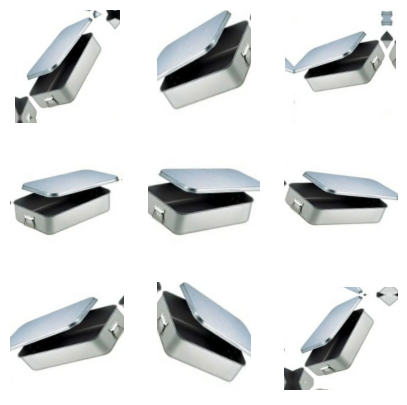

In [46]:
for image, _ in train_data.take(1):  
    plt.figure(figsize=(5, 5))
    first_image = image[0]
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
        plt.imshow(augmented_image[0] / 255)
        plt.axis('off')

Let's combine the model with the augmentation layer, and also add several layers:

* GlobalAveragePooling2D layer, which calculates the arithmetic average over all channels to combine feature maps
* A fully connected layer with 128 neurons and a Dropout layer, which excludes some neurons from the previous fully connected layer with a given probability, thereby reducing the possible effect of overfitting.
* Output fully connected layer with the number of outputs corresponding to the number of classes of our data.

In [47]:
name="MobileNet"

MobileNet_model=tf.keras.Sequential([tf.keras.Input(shape=(None, None, 3), name="input_layer"),
                    data_augmentation,
                    base_model,
                    tf.keras.layers.GlobalAveragePooling2D(),
                    tf.keras.layers.Dense(128, activation='relu'),
                    tf.keras.layers.Dropout(0.2),
                    tf.keras.layers.Dense(len(class_names), activation='softmax')
                    ], name=name)

For training, we will define a loss function, an optimizer, and a tracked accuracy metric

In [48]:
MobileNet_model.compile(loss='categorical_crossentropy',
                              optimizer=tf.keras.optimizers.Adam(learning_rate = 0.001),
                              metrics=['accuracy'])

Let's look at the structure of our model

In [49]:
MobileNet_model.summary()

Model: "MobileNet"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 data_augmentation (Sequenti  (None, None, None, 3)    0         
 al)                                                             
                                                                 
 mobilenet_1.00_224 (Functio  (None, 12, 12, 1024)     3228864   
 nal)                                                            
                                                                 
 global_average_pooling2d (G  (None, 1024)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 128)               131200    
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                         

The summary already shows the advantage of using a pre-trained model - out of more than 20 million parameters, only 165 thousand are trainable, which will significantly reduce training time.

While training the models, we will use a callback function to stop training when the metrics being tracked stop improving. After this, we will save the trained model and weights for further use.

In [50]:
# def log_to_tensorboard(epoch, logs):
#         train_writer.add_scalar('loss', logs['loss'], epoch)
#         train_writer.add_scalar('accuracy', logs['accuracy'], epoch)
#         test_writer.add_scalar('val_loss', logs['val_loss'], epoch)
#         test_writer.add_scalar('val_accuracy', logs['val_accuracy'], epoch)
def log_to_tensorboard(epoch, logs):
    train_writer.add_scalar('loss', logs['loss'], epoch)
    train_writer.add_scalar('accuracy', logs['accuracy'], epoch)
    
    # Use get method with a default value of None to avoid KeyError
    val_loss = logs.get('val_loss', None)
    val_accuracy = logs.get('val_accuracy', None)
    
    if val_loss is not None:
        test_writer.add_scalar('val_loss', val_loss, epoch)
    if val_accuracy is not None:
        test_writer.add_scalar('val_accuracy', val_accuracy, epoch)


# Creating a Callback Function
def create_callback(model_name):
    
    # termination of training when accuracy does not improve within 3 epochs
    early_stop = tf.keras.callbacks.EarlyStopping(patience=3,
                                                monitor="val_loss",
                                                mode="min",
                                                verbose=1)

    # decrease in learning rate when the error rate does not decrease over 2 epochs
    reduce_learning_rate = tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss",
                                                              factor=0.2,
                                                              patience=2,
                                                              verbose=1,
                                                              min_lr=0.00001)

    log_to_tensorboard_callback = tf.keras.callbacks.LambdaCallback(on_epoch_end=lambda epoch, logs: log_to_tensorboard(epoch, logs))
    # saving model
    check_model = tf.keras.callbacks.ModelCheckpoint(model_name + ".h5",
                                                   monitor="val_accuracy",
                                                   mode="max",
                                                   save_best_only=True)
    callback = [early_stop, reduce_learning_rate, check_model, log_to_tensorboard_callback]
    return callback

In [51]:
MobileNet_callback = create_callback(name)

Let's set the number of training epochs

In [52]:
EPOCH=20

Let's train the model

In [53]:
import time
start_time = time.time()
MobileNet_history = MobileNet_model.fit(train_data, 
                                                    epochs=EPOCH, 
                                                    steps_per_epoch=len(train_data),
                                                    validation_data=validation_data, 
                                                    validation_steps=len(validation_data),
                                                    callbacks=MobileNet_callback)

Epoch 1/20
  4/266 [..............................] - ETA: 5:02 - loss: 2.4927 - accuracy: 0.0938

[codecarbon INFO @ 20:20:40] Energy consumed for RAM : 0.000083 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 20:20:40] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 20:20:40] Energy consumed for All CPU : 0.000177 kWh
[codecarbon INFO @ 20:20:40] Energy consumed for all GPUs : 0.000273 kWh. Total GPU Power : 65.36633485874007 W
[codecarbon INFO @ 20:20:40] 0.000533 kWh of electricity and 0.000000 L of water were used since the beginning.


 18/266 [=>............................] - ETA: 4:31 - loss: 2.3404 - accuracy: 0.1424

[codecarbon INFO @ 20:20:55] Energy consumed for RAM : 0.000167 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 20:20:55] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 20:20:55] Energy consumed for All CPU : 0.000354 kWh
[codecarbon INFO @ 20:20:55] Energy consumed for all GPUs : 0.000664 kWh. Total GPU Power : 94.1048586233442 W
[codecarbon INFO @ 20:20:55] 0.001185 kWh of electricity and 0.000000 L of water were used since the beginning.


 32/266 [==>...........................] - ETA: 4:10 - loss: 2.2512 - accuracy: 0.1846

...

182/266 [===================>..........] - ETA: 24s - loss: 1.1356 - accuracy: 0.6161

[codecarbon INFO @ 21:00:25] Energy consumed for RAM : 0.013323 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 21:00:25] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 21:00:25] Energy consumed for All CPU : 0.028315 kWh
[codecarbon INFO @ 21:00:25] Energy consumed for all GPUs : 0.061543 kWh. Total GPU Power : 92.50763889267003 W
[codecarbon INFO @ 21:00:25] 0.103181 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 21:00:25] 0.019421 g.CO2eq/s mean an estimation of 612.4579169295503 kg.CO2eq/year


232/266 [=========================>....] - ETA: 10s - loss: 1.1349 - accuracy: 0.6134

[codecarbon INFO @ 21:00:40] Energy consumed for RAM : 0.013406 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 21:00:40] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 21:00:40] Energy consumed for All CPU : 0.028492 kWh
[codecarbon INFO @ 21:00:40] Energy consumed for all GPUs : 0.061927 kWh. Total GPU Power : 92.34767550563136 W
[codecarbon INFO @ 21:00:40] 0.103825 kWh of electricity and 0.000000 L of water were used since the beginning.


266/266 [==============================] - 83s 310ms/step - loss: 1.1431 - accuracy: 0.6080 - val_loss: 0.9494 - val_accuracy: 0.6792 - lr: 4.0000e-05


Based on the training history, you can evaluate the effectiveness of using our callback function - after reducing the learning speed, the errors also decreased.

Out the logs folder for further analysis

In [54]:
import shutil

# Create a zip archive of the output folder
shutil.make_archive("/kaggle/working/logs", 'zip', "/kaggle/working/logs")

'/kaggle/working/logs.zip'

Let's look at the model training schedules.

In [55]:
end_time = time.time()
training_time = end_time - start_time
develop_model_emissions: float = develop_model_emission_tracker.stop()
print(f"Develop Model Carbon Emissions: {develop_model_emissions} kg")
print("Total training time: {:.2f} seconds".format(training_time))
MobileNet_model.save("/kaggle/working/garbage-classification.h5")

[codecarbon INFO @ 21:00:57] Energy consumed for RAM : 0.013499 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 21:00:57] Delta energy consumed for CPU with constant : 0.000021 kWh, power : 42.5 W
[codecarbon INFO @ 21:00:57] Energy consumed for All CPU : 0.028690 kWh
[codecarbon INFO @ 21:00:57] Energy consumed for all GPUs : 0.062324 kWh. Total GPU Power : 56.17906763235387 W
[codecarbon INFO @ 21:00:57] 0.104513 kWh of electricity and 0.000000 L of water were used since the beginning.


Develop Model Carbon Emissions: 0.047304764926324225 kg
Total training time: 2426.51 seconds


Close the SummaryWriter

In [56]:
writer.close()
train_writer.close()
test_writer.close()

In [57]:
MobileNet_history.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy', 'lr'])

In [58]:
# Function for displaying training graphs
def plot_loss_curves(history):

    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    
    accuracy = history.history["accuracy"]
    val_accuracy = history.history["val_accuracy"]
    
    epochs = range(len(history.history["loss"]))
    
    plt.plot(epochs, loss, label="training_loss")
    plt.plot(epochs, val_loss, label="val_loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()
    
    plt.figure()
    plt.plot(epochs, accuracy, label="training_accuracy")
    plt.plot(epochs, val_accuracy, label="val_accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend()

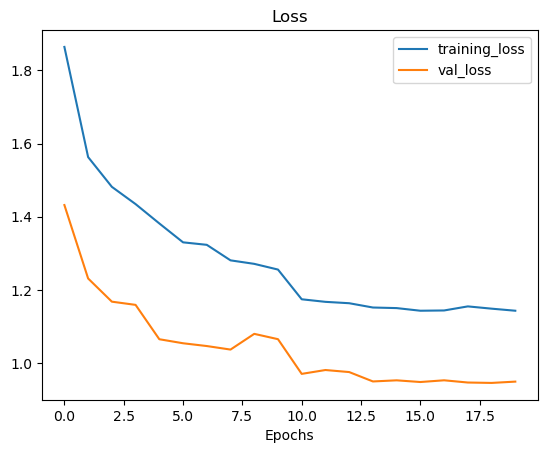

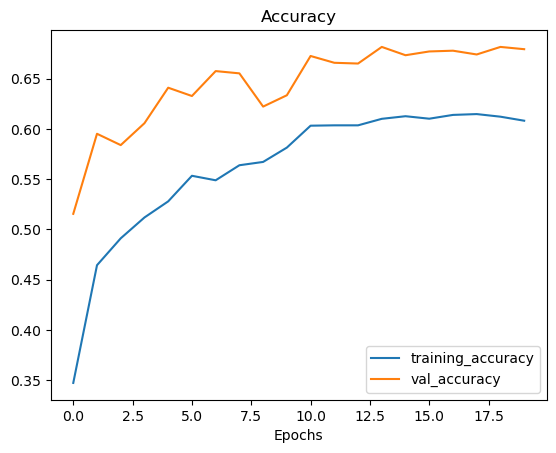

In [59]:
plot_loss_curves(MobileNet_history)

The learning curves look a little jumpy, but the dynamics look pretty good, there is a decrease in learning losses and an increase in testing accuracy.

# Model Evaluation

We use a set of test data to evaluate the accuracy of the model on new data

In [60]:
test_loss, test_accuracy = MobileNet_model.evaluate(test_data, verbose=0)

In [61]:
print("Test Loss: {:.5f}".format(test_loss))
print("Test Accuracy: {:.2f}%".format(test_accuracy * 100))

Test Loss: 1.01643
Test Accuracy: 65.47%


Given the limited data set, we obtained a good accuracy of 97%.

Let's look at the main classification metrics

In [62]:
pred_probs = MobileNet_model.predict(test_data, verbose=1)

42/42 [==============================] - 5s 113ms/step


In [63]:
pred_classes = pred_probs.argmax(axis=1)
pred_classes[:10]

array([7, 0, 0, 0, 2, 0, 0, 0, 0, 0])

In [64]:
y_labels = []
for images, labels in test_data.unbatch(): 
    y_labels.append(labels.numpy().argmax()) 
y_labels[:10] 

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Since the images in the test dataset were not shuffled, all the output labels correspond to the same class.

In [65]:
print('Classification Report \n')
target_names = class_names
print(classification_report(y_labels, pred_classes, target_names=target_names))

Classification Report 

              precision    recall  f1-score   support

     battery       0.68      0.80      0.74        82
  biological       0.84      0.81      0.82        81
   cardboard       0.71      0.73      0.72       154
     clothes       0.80      0.86      0.83       199
       glass       0.74      0.43      0.55       201
       metal       0.49      0.42      0.45       100
       paper       0.45      0.66      0.53       138
     plastic       0.54      0.52      0.53       172
       shoes       0.71      0.81      0.76       164
       trash       0.62      0.40      0.49        50

    accuracy                           0.65      1341
   macro avg       0.66      0.65      0.64      1341
weighted avg       0.66      0.65      0.65      1341



* The “Precision” column shows the percentage of correct predictions among all predictions for a particular class.
* The "Recall" column shows the percentage of images of a particular class that were predicted by the model to belong to that class.
* Column “F1” shows what percentage of model predictions were correct.
* The "Support" column shows how many images of each class were in the test dataset.

From the summary of metrics it is clear that the model classifies plastic worst of all, and best of all - things and various biological waste. However, despite the small data set, the model shows excellent performance in terms of Precision, Recall and F1 scores.

We visualize the error matrix to clearly see the correctness of class definitions

In [66]:
import itertools

In [67]:
def plot_confusion_matrix(cm, classes):
    plt.figure(figsize=(7,7))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion matrix')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    cm = np.around(cm, decimals=2)
    cm[np.isnan(cm)] = 0.0
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

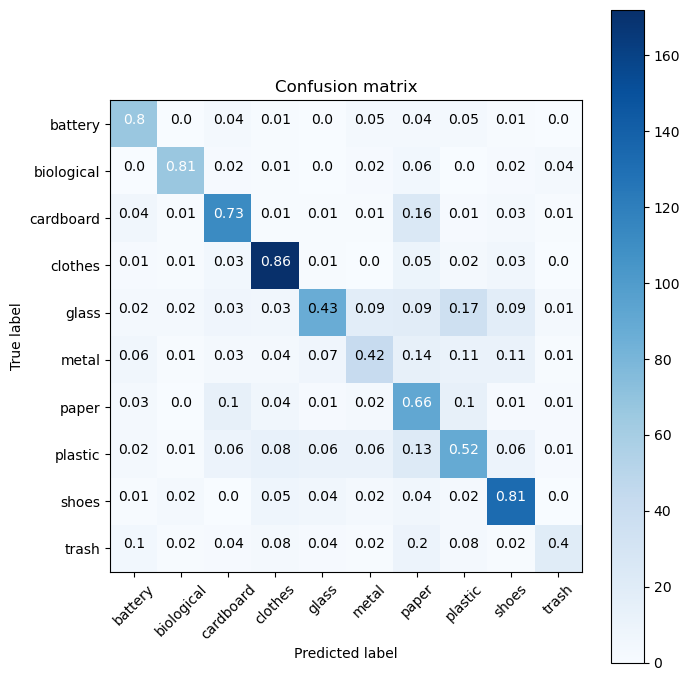

In [68]:
cm = confusion_matrix(y_labels, pred_classes)
plot_confusion_matrix(cm, class_names)

The rows of the matrix are responsible for the class predicted by the model, and the columns are for the actual class. From the error matrix, it is noticeable that in general the model’s errors are very small, although it sometimes incorrectly predicts categories, for example, it confuses plastic and glass.

Visualizing several model predictions

In [69]:
def pred_random_images(model_name, folder_path, class_names):
    plt.figure(figsize=(17, 10))
    for i in range(3):
        class_name = random.choice(class_names)
        filename = random.choice(os.listdir(folder_path + "/" + class_name))
        filepath = folder_path + "/" + class_name + "/" + filename
    
        img = tf.io.read_file(filepath)
        img = tf.image.decode_jpeg(img)
        img = tf.image.resize(img, [IMG_SIZE[0], IMG_SIZE[1]])
     #  img = img/255.
        if i == 1:
            deploy_model_emission_tracker = EmissionsTracker()
            deploy_model_emission_tracker.start()
            pred_prob = model_name.predict(tf.expand_dims(img, axis=0), verbose=0)
            deploy_model_emissions: float = prepare_data_emission_tracker.stop()
            print(f"Deploy Model Carbon Emissions: {deploy_model_emissions} kg")
        else:
            pred_prob = model_name.predict(tf.expand_dims(img, axis=0), verbose=0)
            pred_class = class_names[pred_prob.argmax()]

  # Plot the image(s)
        plt.subplot(1, 3, i+1)
        plt.imshow(img/255.)
        if class_name == pred_class: 
            title_color = "g"
        else:
            title_color = "r"
        plt.title(f"Class: {class_name},\n Pred: {pred_class},\n Prob: {pred_prob.max():.2f}", c=title_color)
        plt.axis(False);

[codecarbon WARNING @ 21:01:31] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 21:01:31] [setup] RAM Tracking...
[codecarbon INFO @ 21:01:31] [setup] CPU Tracking...
[codecarbon WARNING @ 21:01:31] We saw that you have a Intel(R) Xeon(R) CPU @ 2.00GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 21:01:31] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 21:01:31] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.00GHz
[codecarbon WARNING @ 21:01:31] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 21:01:31] [setup] GPU Tracking...
[codecarbon INFO @ 21:01:31] Tracking Nvidia GPU via pynvml
[codecarbon INFO @ 21:01:31] The below tracking methods have been set up:
                RAM Tracking Method: RAM po

Deploy Model Carbon Emissions: 0.04915627075662602 kg


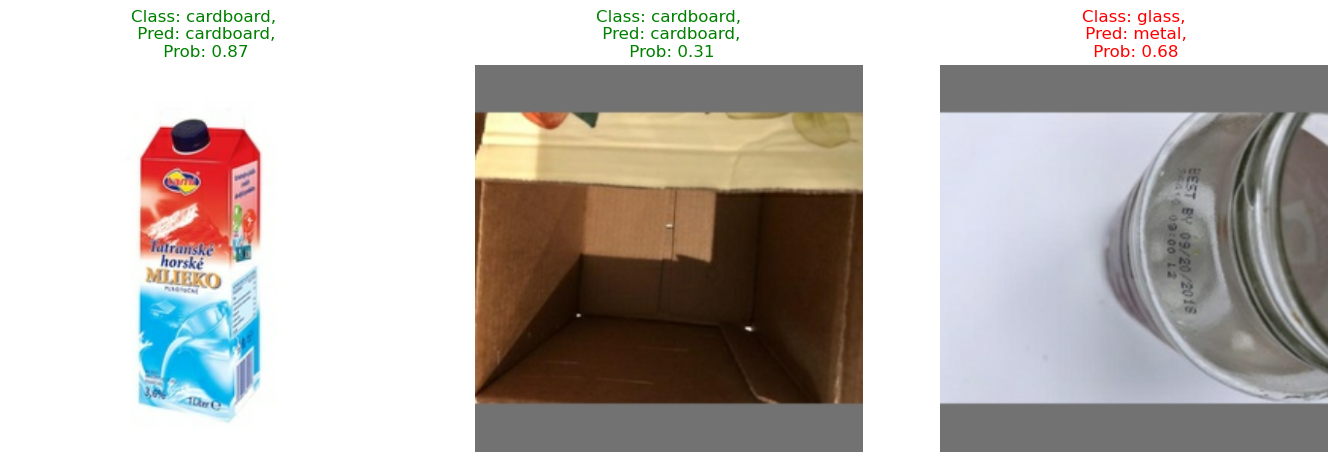

In [70]:
pred_random_images(MobileNet_model, test_path, class_names)

In [71]:
import pickle
pickle.dump(MobileNet_model,open("MobileNet_model.h5","wb"))

In [72]:
ls ../working

MobileNet.h5        data/                      logs/
MobileNet_model.h5  emissions.csv              logs.zip
__notebook__.ipynb  garbage-classification.h5  runs/
